# FlowCast EDA — Northline Corridor

Week-1 exit artefact (PRD §17). Loads the **cleaned, merged** dataset produced by
`python run_pipeline.py data` and documents the distributions, correlations and
insights that drove the modelling choices in Weeks 2–3.

**Grain:** segment × 30-minute window · **Coverage:** 25 segments, 2025-01-01 → 2025-05-31

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path('../data/processed/flowcast_processed.parquet')
df = pd.read_parquet(PROCESSED)
print(df.shape)
df.head(3)

(181200, 30)


,date,time,road_id,road_name,latitude,longitude,weather_station_id,traffic_volume,vehicle_count,avg_speed,...,share_hcv,weather_condition,temperature,rainfall,visibility,public_holiday,holiday_name,event_flag,event_name,roadwork_flag
0,2025-01-01,00:00,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,97.0,97.0,53.0,...,0.14,Clear,12.7,0.0,10000.0,1,New Year's Day,0,,0
1,2025-01-01,00:30,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,99.0,99.0,56.7,...,0.12,Clear,12.7,0.0,10000.0,1,New Year's Day,0,,0
2,2025-01-01,01:00,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,102.0,102.0,55.7,...,0.07,Clear,8.8,0.0,10000.0,1,New Year's Day,0,,0


## 1. Data-quality summary
Every defect in the raw feed and its resolution is quantified in
`reports/data_quality_report.md` (generated alongside this notebook).
Headline: 178,469 raw rows → 181,200 clean records after duplicate removal
(1,767), outlier repair (704 impossible values), restoration of 4,499 dropped
sensor windows, and derivation of 31,123 blank congestion labels from the V/C banding.

In [2]:
qc = pd.read_csv('../reports/_quality_log.csv') if Path('../reports/_quality_log.csv').exists() else None
print('nulls in modelling columns:', int(df[['traffic_volume','avg_speed','occupancy','congestion_level','weather_condition']].isna().sum().sum()))
print('key duplicates:', int(df.duplicated(subset=['road_id','timestamp']).sum()))
print('volume range:', df.traffic_volume.min(), '-', df.traffic_volume.max())

nulls in modelling columns: 0
key duplicates: 0
volume range: 41.0 - 2090.0


## 2. Volume rhythm — time of day and day of week
Strong, stable AM/PM peaks on weekdays; weekends shift demand to midday.
This motivated the cyclical hour/day encodings and the t−48 (same window
yesterday) lag feature.

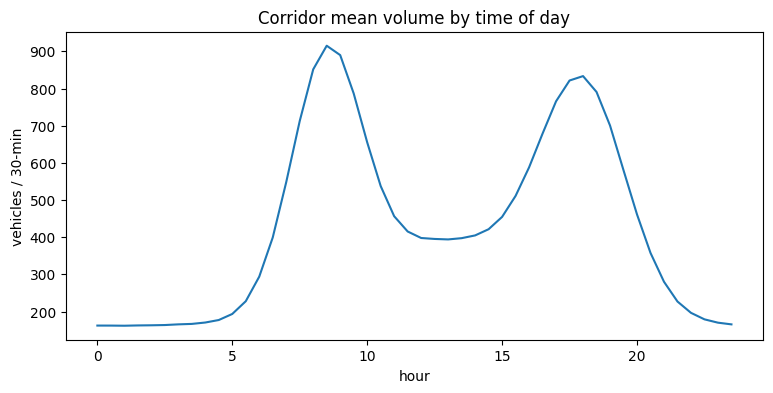

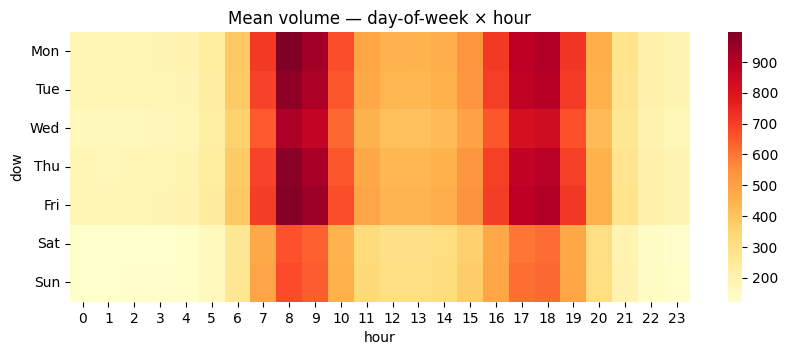

In [3]:
hourly = df.assign(hour=df.timestamp.dt.hour + df.timestamp.dt.minute/60).groupby('hour')['traffic_volume'].mean()
fig, ax = plt.subplots(figsize=(9, 4))
hourly.plot(ax=ax)
ax.set_title('Corridor mean volume by time of day'); ax.set_ylabel('vehicles / 30-min')
plt.show()

pivot = df.assign(dow=df.timestamp.dt.dayofweek, hour=df.timestamp.dt.hour).pivot_table(
    index='dow', columns='hour', values='traffic_volume', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax)
ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
ax.set_title('Mean volume — day-of-week × hour')
plt.show()

## 3. Congestion structure
The corridor is free-flowing most of the day; Heavy/Severe states concentrate
in weekday peaks. Class imbalance (≈62 % Free-flow) motivated macro-F1 as the
headline classification metric instead of accuracy.

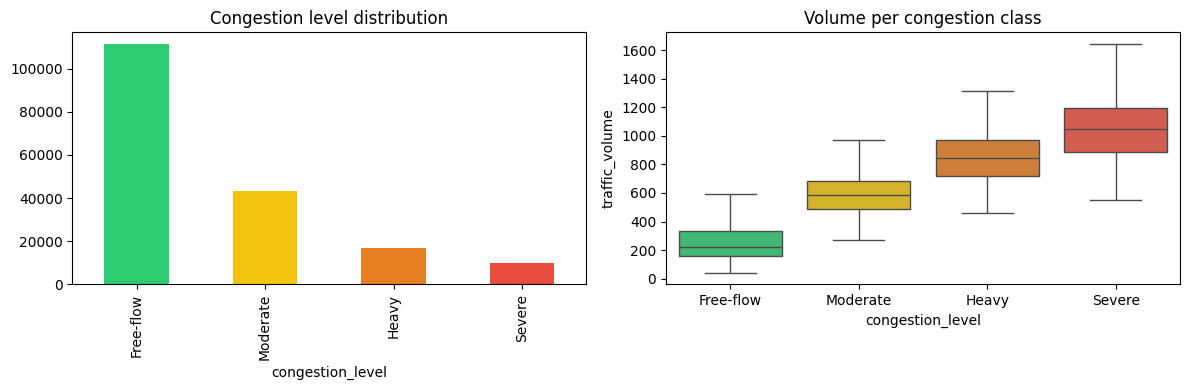

{'Free-flow': 0.614, 'Moderate': 0.239, 'Heavy': 0.093, 'Severe': 0.055}


In [4]:
order = ['Free-flow', 'Moderate', 'Heavy', 'Severe']
vc = df.congestion_level.value_counts().reindex(order)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc.plot.bar(ax=axes[0], color=['#2ecc71','#f1c40f','#e67e22','#e74c3c'])
axes[0].set_title('Congestion level distribution')
sns.boxplot(data=df, x='congestion_level', y='traffic_volume', order=order,
            hue='congestion_level', palette={'Free-flow':'#2ecc71','Moderate':'#f1c40f','Heavy':'#e67e22','Severe':'#e74c3c'}, legend=False, ax=axes[1], showfliers=False)
axes[1].set_title('Volume per congestion class')
plt.tight_layout(); plt.show()
print((vc / vc.sum()).round(3).to_dict())

## 4. Weather impact
Rain and Fog visibly degrade flow — mean speed drops and accident rates rise
≈4×. Weather features (rain flag, low-visibility flag, condition one-hots)
are therefore kept as first-class model inputs.

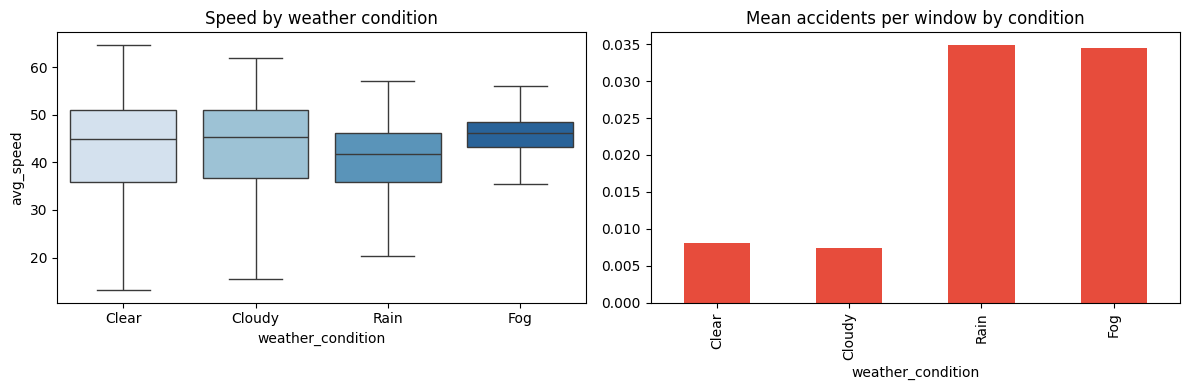

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='weather_condition', y='avg_speed',
            hue='weather_condition', order=['Clear','Cloudy','Rain','Fog'],
            palette='Blues', legend=False, ax=axes[0], showfliers=False)
axes[0].set_title('Speed by weather condition')
df.groupby('weather_condition')['accident_count'].mean().reindex(
    ['Clear','Cloudy','Rain','Fog']).plot.bar(ax=axes[1], color='#e74c3c')
axes[1].set_title('Mean accidents per window by condition')
plt.tight_layout(); plt.show()

## 5. Correlations and redundancy
Volume, occupancy and congestion move together (V/C derivation is visible as
near-perfect correlation); lag and rolling features capture momentum without
leaking the target. Speed is negatively correlated with volume.

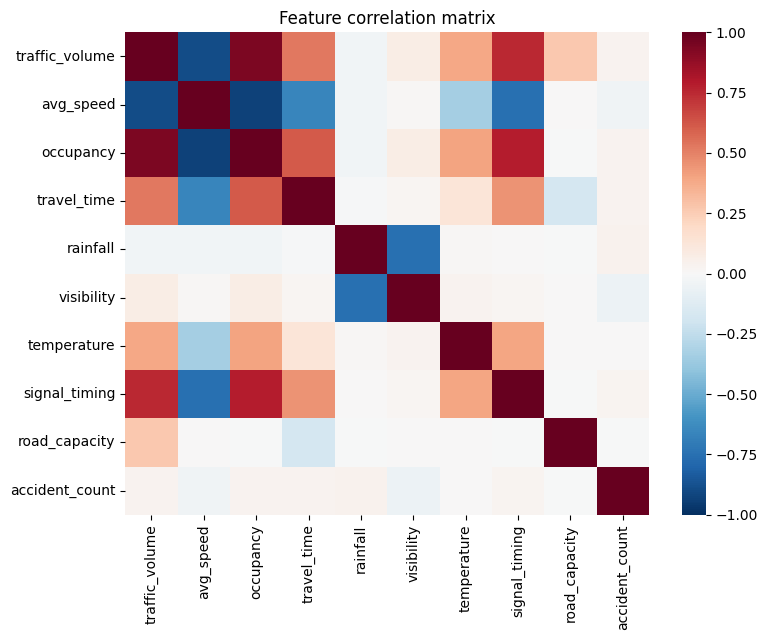

In [6]:
num = ['traffic_volume','avg_speed','occupancy','travel_time','rainfall',
       'visibility','temperature','signal_timing','road_capacity','accident_count']
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(df[num].corr(), cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout(); plt.show()

## 6. Insights that drove modelling

1. **Strong daily periodicity + momentum** → cyclical encodings, t−1/t−2/t−48 lags,
   rolling means/std; a recurrent model should add trajectory awareness.
2. **Weather degradation** → rain/low-visibility flags and condition one-hots.
3. **Class imbalance** → macro-F1 headline; class weighting for accident risk.
4. **Time is the only honest split** → train/val/test by timeline, scalers fit on
   train only, lags computed strictly within segments.
5. **Accident signal is weak** (≈0.9 % prevalence, Bayes ceiling ≈ 0.68 AUC) →
   risk model expectations calibrated in the final report.